
# Algebra and Trigonometry for Modern Physics and Photonics

**Purpose:** Build the math foundation for modern physics, photonics, circuits, Fourier analysis, and scientific computing.

This notebook moves from algebra and trigonometry into complex waves, photons, simple Fourier ideas, and optical intensity.

Safe focus: education, simulation, measurement, and scientific intuition.


In [9]:

# Cell 1 - Setup

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

sp.init_printing(use_unicode=True)

x, t, theta, omega, k, A, phi = sp.symbols("x t theta omega k A phi", real=True)
I = sp.I

print("Notebook ready.")


Notebook ready.



## 1. Algebra: equations, functions, and units

Algebra is the language of solving for unknowns.

In physics, the unknown might be time, distance, wavelength, frequency, voltage, current, or energy.


In [10]:

# Cell 2 - Solve basic physics equations symbolically

v, d, tau = sp.symbols("v d tau", positive=True)

equation = sp.Eq(d, v*tau)
solution_for_time = sp.solve(equation, tau)[0]

print("Equation:")
display(equation)

print("Solved for time:")
display(solution_for_time)

example_time = solution_for_time.subs({d: 300, v: 3e8})
print("Example time in seconds:")
display(example_time)


Equation:


Solved for time:


Example time in seconds:



## 2. Exponentials and logarithms

Exponentials describe growth, decay, absorption, and probability tails.

Logarithms undo exponentials and help solve for time, distance, or attenuation.


In [11]:

# Cell 3 - Exponential decay and logarithms

alpha, L = sp.symbols("alpha L", positive=True)

intensity = sp.exp(-alpha*L)
target = sp.Rational(1, 2)

solve_length = sp.solve(sp.Eq(intensity, target), L)[0]

print("Intensity after absorption:")
display(intensity)

print("Solve exp(-alpha L) = 1/2 for L:")
display(solve_length)

display(solve_length.subs(alpha, 0.7))


Intensity after absorption:


Solve exp(-alpha L) = 1/2 for L:



## 3. Trigonometry and waves

Sine and cosine describe oscillations.

Light, sound, AC circuits, and quantum wavefunctions all use oscillatory mathematics.


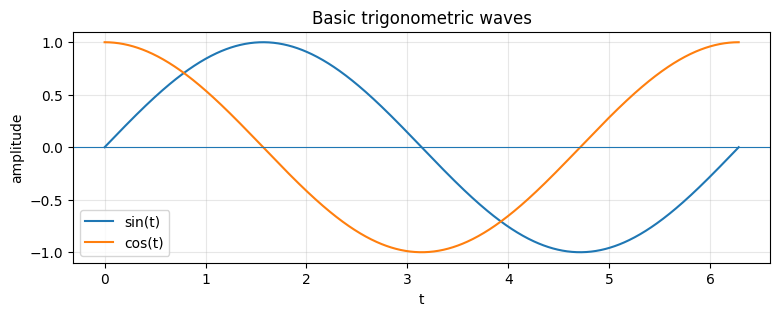

In [12]:

# Cell 4 - Plot sine and cosine waves

tt = np.linspace(0, 2*np.pi, 800)

plt.figure(figsize=(9, 3))
plt.plot(tt, np.sin(tt), label="sin(t)")
plt.plot(tt, np.cos(tt), label="cos(t)")
plt.axhline(0, linewidth=0.8)
plt.title("Basic trigonometric waves")
plt.xlabel("t")
plt.ylabel("amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 4. Euler's formula

Euler's formula is the bridge from trigonometry to modern physics:

$$e^{i\theta}=\cos(\theta)+i\sin(\theta)$$

This is how waves are represented in quantum mechanics and photonics.


In [13]:

# Cell 5 - Euler formula in SymPy

expr = sp.exp(I*theta)
expanded = sp.expand_complex(expr)

print("Complex exponential:")
display(expr)

print("Expanded using Euler form:")
display(expanded)

E = A * sp.exp(I*(omega*t + phi))
print("Optical/quantum-style complex field:")
display(E)

print("Complex conjugate:")
display(sp.conjugate(E))

print("Intensity |E|^2 = E * E.conjugate():")
display(sp.simplify(E * sp.conjugate(E)))


Complex exponential:


Expanded using Euler form:


Optical/quantum-style complex field:


Complex conjugate:


Intensity |E|^2 = E * E.conjugate():



## 5. Vectors and components

Vectors describe fields, forces, motion, polarization, and wave propagation.

A 2D vector can be written using magnitude and angle:

$$x=r\cos\theta,\qquad y=r\sin\theta$$


In [14]:

# Cell 6 - Vector components

r = sp.symbols("r", positive=True)

vx = r*sp.cos(theta)
vy = r*sp.sin(theta)

print("Vector x-component:")
display(vx)

print("Vector y-component:")
display(vy)

print("Magnitude check:")
display(sp.simplify(sp.sqrt(vx**2 + vy**2)))


Vector x-component:


Vector y-component:


Magnitude check:



## 6. Fourier idea: a signal is built from waves

Fourier analysis says complicated signals can be represented using sums of sine, cosine, or complex exponential waves.

This idea powers optics, image processing, signal processing, quantum mechanics, communications, and phase retrieval.


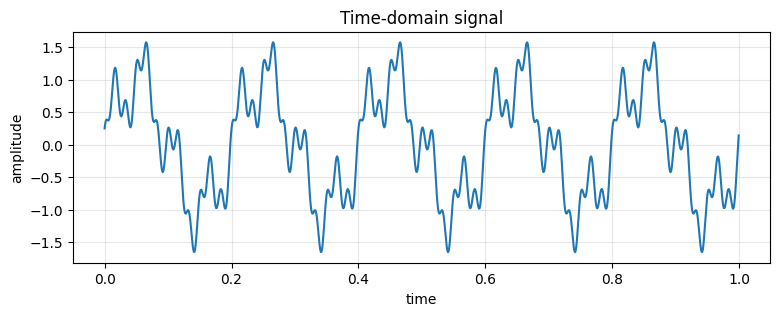

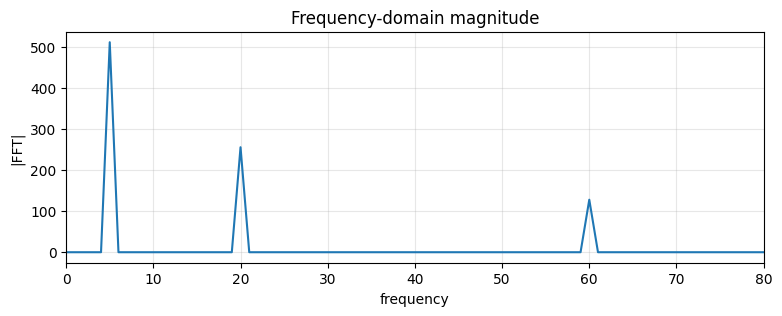

In [15]:

# Cell 7 - Numerical Fourier demo

N = 1024
tt = np.linspace(0, 1, N, endpoint=False)

signal = (
    1.0*np.sin(2*np.pi*5*tt)
    + 0.5*np.sin(2*np.pi*20*tt)
    + 0.25*np.cos(2*np.pi*60*tt)
)

freq = np.fft.fftfreq(N, d=tt[1]-tt[0])
spectrum = np.fft.fft(signal)

plt.figure(figsize=(9, 3))
plt.plot(tt, signal)
plt.title("Time-domain signal")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 3))
mask = freq >= 0
plt.plot(freq[mask], np.abs(spectrum[mask]))
plt.xlim(0, 80)
plt.title("Frequency-domain magnitude")
plt.xlabel("frequency")
plt.ylabel("|FFT|")
plt.grid(True, alpha=0.3)
plt.show()



## 7. Modern physics: photons

Photon energy is

$$E = hf = \frac{hc}{\lambda}$$

This connects frequency, wavelength, and energy.


In [16]:

# Cell 8 - Photon energy

h, c, lam = sp.symbols("h c lambda", positive=True)

photon_energy = h*c/lam

print("Photon energy:")
display(photon_energy)

# Numeric example: 1550 nm telecom photon
h_val = 6.62607015e-34
c_val = 299792458
lam_val = 1550e-9

E_joule = photon_energy.subs({h: h_val, c: c_val, lam: lam_val})
E_eV = E_joule / 1.602176634e-19

print("1550 nm photon energy in joules:")
display(sp.N(E_joule, 4))

print("1550 nm photon energy in eV:")
display(sp.N(E_eV, 4))


Photon energy:


1550 nm photon energy in joules:


1550 nm photon energy in eV:



## 8. Photonics: intensity hides phase

A detector usually measures intensity:

$$I(t)=|E(t)|^2$$

The phase is not directly visible in basic intensity measurements.


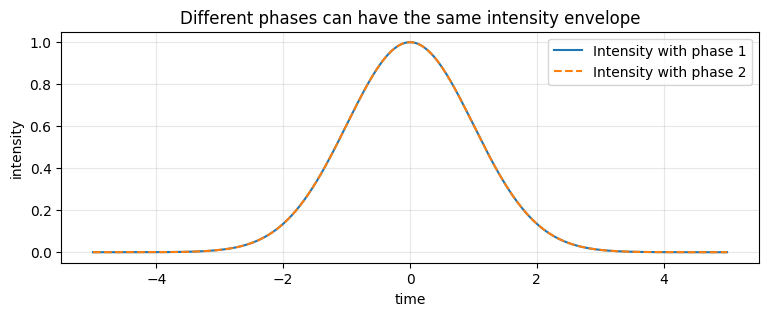

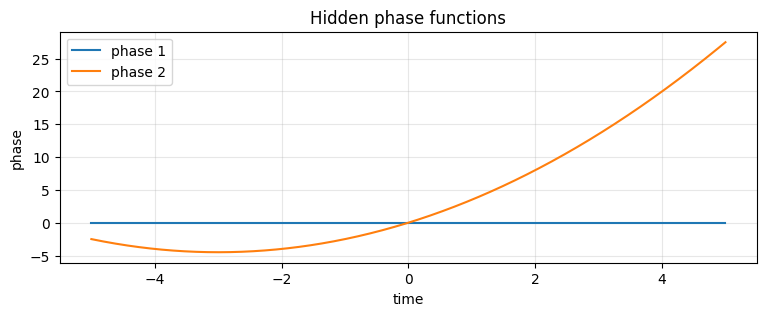

In [17]:

# Cell 9 - Phase changes without changing intensity

tt = np.linspace(-5, 5, 1000)

amp = np.exp(-tt**2/4)
phase1 = 0.0 * tt
phase2 = 3.0*tt + 0.5*tt**2

E1 = amp * np.exp(1j*phase1)
E2 = amp * np.exp(1j*phase2)

I1 = np.abs(E1)**2
I2 = np.abs(E2)**2

plt.figure(figsize=(9, 3))
plt.plot(tt, I1, label="Intensity with phase 1")
plt.plot(tt, I2, "--", label="Intensity with phase 2")
plt.title("Different phases can have the same intensity envelope")
plt.xlabel("time")
plt.ylabel("intensity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(9, 3))
plt.plot(tt, phase1, label="phase 1")
plt.plot(tt, phase2, label="phase 2")
plt.title("Hidden phase functions")
plt.xlabel("time")
plt.ylabel("phase")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 9. Calculus preview: derivatives and integrals

Derivatives measure change. Integrals accumulate quantities.

In photonics and physics:

- derivative of phase gives frequency shift or group delay
- integral of intensity gives energy
- surface integral gives flux
- volume integral gives total charge or probability


In [18]:

# Cell 10 - Derivative and integral with SymPy

phase = omega*t + sp.Rational(1, 2)*k*t**2

print("Phase:")
display(phase)

print("Derivative of phase:")
display(sp.diff(phase, t))

pulse_intensity = sp.exp(-t**2)

print("Gaussian pulse intensity:")
display(pulse_intensity)

print("Total area/energy-like integral:")
display(sp.integrate(pulse_intensity, (t, -sp.oo, sp.oo)))


Phase:


Derivative of phase:


Gaussian pulse intensity:


Total area/energy-like integral:



## 10. Final roadmap

If you do this right, the path is:

```text
Algebra
  -> Trigonometry
  -> Complex numbers
  -> Vectors
  -> Calculus
  -> Fourier analysis
  -> Modern physics
  -> Electromagnetism
  -> Photonics
  -> Phase retrieval
  -> Scientific AI
```

This notebook is the foundation layer.


In [ ]:
import random
import sympy as sp

sp.init_printing(use_unicode=True)

N = sp.symbols("N", positive=True, integer=True)

print("Random walk uncertainty model")
print("Press Enter to start.")
input()

position = 0
steps = []

for n in range(1, 21):
    step = random.choice([-1, 1])
    position += step
    steps.append(position)

    print(f"step {n:2d}: move {step:+d}, position = {position:+d}")
    input("Press Enter for next step...")

print("\nSymbolic uncertainty after N steps:")
display(sp.sqrt(N))

print("For 20 steps:")
display(sp.sqrt(20))f

Random walk uncertainty model
Press Enter to start.
step  1: move -1, position = -1
step  2: move +1, position = +0
step  3: move -1, position = -1
step  4: move +1, position = +0
step  5: move +1, position = +1


In [ ]:
# Fog-of-War Algebra Explorer
# Algebra -> Physics -> Random Walk -> Explainable AI logic

import random
import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing(use_unicode=True)

# -----------------------------
# 1. Symbols
# -----------------------------
x, t, v, a = sp.symbols("x t v a", real=True)
f, lam, omega = sp.symbols("f lambda omega", positive=True)
N, sigma = sp.symbols("N sigma", positive=True)
E, A, theta = sp.symbols("E A theta", real=True)
I = sp.I

# -----------------------------
# 2. Equation library
# -----------------------------
equations = {
    "constant_velocity": sp.Eq(x, v*t),
    "acceleration": sp.Eq(x, sp.Rational(1, 2)*a*t**2),
    "wave_speed": sp.Eq(v, f*lam),
    "angular_frequency": sp.Eq(omega, 2*sp.pi*f),
    "random_walk_uncertainty": sp.Eq(sigma, sp.sqrt(N)),
    "complex_wave": sp.Eq(E, A*sp.exp(I*theta)),
}

# -----------------------------
# 3. Display equations
# -----------------------------
print("Available algebra/physics models:")
for name, eq in equations.items():
    print("\n", name)
    display(eq)

# -----------------------------
# 4. Fog-of-war classifier rules
# -----------------------------
def classify_problem(words):
    words = words.lower()

    scores = {
        "motion": 0,
        "wave": 0,
        "uncertainty": 0,
        "complex_physics": 0,
    }

    if any(w in words for w in ["walk", "random", "diffusion", "uncertain"]):
        scores["uncertainty"] += 2

    if any(w in words for w in ["velocity", "distance", "acceleration", "motion"]):
        scores["motion"] += 2

    if any(w in words for w in ["wave", "frequency", "wavelength", "photon", "light"]):
        scores["wave"] += 2

    if any(w in words for w in ["complex", "phase", "quantum", "fourier"]):
        scores["complex_physics"] += 2

    winner = max(scores, key=scores.get)
    return winner, scores

# -----------------------------
# 5. Example prompt
# -----------------------------
prompt = "random walk uncertainty algebra physics wave"
winner, scores = classify_problem(prompt)

print("\nPrompt:", prompt)
print("Scores:", scores)
print("Selected model family:", winner)

# -----------------------------
# 6. Decision tree explanation
# -----------------------------
def decision_tree_explain(words):
    print("\nDecision path:")

    if "random" in words or "walk" in words:
        print("Detected random/walk -> uncertainty model")
        return "random_walk_uncertainty"

    if "wave" in words or "frequency" in words:
        print("Detected wave/frequency -> wave speed model")
        return "wave_speed"

    if "acceleration" in words:
        print("Detected acceleration -> kinematics model")
        return "acceleration"

    if "velocity" in words or "distance" in words:
        print("Detected velocity/distance -> constant velocity model")
        return "constant_velocity"

    if "phase" in words or "complex" in words:
        print("Detected phase/complex -> complex wave model")
        return "complex_wave"

    print("No strong signal -> default to algebra model")
    return "constant_velocity"

selected = decision_tree_explain(prompt)
display(equations[selected])

# -----------------------------
# 7. Random forest style voting
# -----------------------------
def tree_vote(words, seed):
    random.seed(seed)

    candidates = list(equations.keys())

    if "random" in words or "walk" in words:
        return random.choice(["random_walk_uncertainty", "random_walk_uncertainty", "wave_speed"])

    if "wave" in words:
        return random.choice(["wave_speed", "angular_frequency", "complex_wave"])

    if "motion" in words:
        return random.choice(["constant_velocity", "acceleration"])

    return random.choice(candidates)

votes = []
for seed in range(25):
    votes.append(tree_vote(prompt, seed))

vote_counts = {v: votes.count(v) for v in sorted(set(votes))}

print("\nRandom forest votes:")
for k, val in vote_counts.items():
    print(k, val)

forest_choice = max(vote_counts, key=vote_counts.get)
print("\nForest selected:", forest_choice)
display(equations[forest_choice])

# -----------------------------
# 8. Solve selected equation
# -----------------------------
eq = equations[forest_choice]

print("\nSelected equation:")
display(eq)

print("Solve options:")
for symbol in eq.free_symbols:
    try:
        sol = sp.solve(eq, symbol)
        print("solve for", symbol)
        display(sol)
    except Exception:
        pass

# -----------------------------
# 9. Random walk simulation
# -----------------------------
steps = 200
position = 0
positions = [position]

for n in range(steps):
    step = random.choice([-1, 1])
    position += step
    positions.append(position)

plt.figure(figsize=(10, 3))
plt.plot(positions)
plt.title("Random walk: uncertainty grows with steps")
plt.xlabel("step")
plt.ylabel("position")
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 10. Many random walks
# -----------------------------
trials = 500
final_positions = []

for trial in range(trials):
    position = 0
    for n in range(steps):
        position += random.choice([-1, 1])
    final_positions.append(position)

mean_final = np.mean(final_positions)
std_final = np.std(final_positions)

print("Mean final position:", mean_final)
print("Standard deviation:", std_final)
print("Theoretical sqrt(N):", math.sqrt(steps))

plt.figure(figsize=(8, 3))
plt.hist(final_positions, bins=30)
plt.title("Distribution of final random-walk positions")
plt.xlabel("final position")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 11. Algebra connection
# -----------------------------
Xi = sp.symbols("X_1:" + str(6))
S = sum(Xi)

print("\nSymbolic random walk sum:")
display(sp.Eq(sp.Symbol("S_5"), S))

print("Uncertainty scaling:")
display(sp.Eq(sigma, sp.sqrt(N)))

# -----------------------------
# 12. Wave visualization
# -----------------------------
tt = np.linspace(0, 1, 1000)
wave = np.sin(2*np.pi*5*tt)

plt.figure(figsize=(10, 3))
plt.plot(tt, wave)
plt.title("Simple wave: sin(2*pi*f*t)")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 13. Fourier-style signal
# -----------------------------
signal = (
    np.sin(2*np.pi*5*tt)
    + 0.5*np.sin(2*np.pi*20*tt)
    + 0.2*np.cos(2*np.pi*60*tt)
)

freq = np.fft.fftfreq(len(tt), d=tt[1] - tt[0])
spectrum = np.fft.fft(signal)

plt.figure(figsize=(10, 3))
plt.plot(tt, signal)
plt.title("Signal built from several waves")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 3))
mask = freq >= 0
plt.plot(freq[mask], np.abs(spectrum[mask]))
plt.xlim(0, 80)
plt.title("Frequency-domain view")
plt.xlabel("frequency")
plt.ylabel("magnitude")
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 14. Complex wave
# -----------------------------
complex_wave = sp.exp(I*theta)

print("\nEuler / complex wave:")
display(complex_wave)
display(sp.expand_complex(complex_wave))

# -----------------------------
# 15. Fog-of-war report
# -----------------------------
print("\nFOG-OF-WAR REPORT")
print("-----------------")
print("Input prompt:", prompt)
print("Decision-tree choice:", selected)
print("Random-forest choice:", forest_choice)
print("Uncertainty model: sigma = sqrt(N)")
print("Physics meaning: many possible paths, only statistical prediction")
print("Coding meaning: inspect algebra before committing to implementation")
print("Next step: turn this into a notebook with sliders and cleaner functions")